<a href="https://colab.research.google.com/github/MathuMoorthy/BREAST-CANCER-PREDICTION/blob/main/Brain_Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
!ls /content/drive/MyDrive/


'10th mark sheet original.jpg'
'10th mark sheet.pdf'
'11th mark sheet original.jpg'
'12th mark sheet 2 pdf.pdf'
'12th mark sheet 3.pdf'
'12th mark sheet original.jpg'
 21CS127.pdf
'90-IMG_20210820_171625_copy_1412x1798 (3).JPG'
 Aadhar.pdf
 basic.c
 basic.exe
'block diagram.drawio'
 Brain_tumor_dataset
 Classroom
'Colab Notebooks'
'college fee..pdf'
'community certificate.pdf'
'community original.jpg'
'Copy of Curious Freaks Coding Sheet.gsheet'
'covi vaccination certificate.pdf'
'DCE _ Application form.pdf'
 division.cpp
 division.exe
'Document from Mathu.pdf'
 EG.pdf
'fee receipt.pdf'
 float.c
 float.exe
'Grade Sheet Sem 1 and 2 _21CS099 Mathumitha.pdf'
 helloworld.c
 helloworld.exe
'Hostel fee receipt.pdf'
 IMG_20210820_171625_copy_1412x1798.jpg
'Internship Certificate2_Mathumitha.pdf'
'Internship VEI TECHNOLOGY.pdf'
'Kirthick S 20CSL04.pdf'
"Madhumitha's horoscope.pdf"
'MATHS CALCULUS MCQS.gdoc'
'Mathumitha ID.jpeg'
'MATHUMITHA M_21CS099.gdoc'
'MATHUMITHA M_21CS099.pdf'
'MATHUMITHA

In [6]:
!ls /content/drive/MyDrive/Brain_tumor_dataset/


archive.zip


In [7]:
!unzip '/content/drive/MyDrive/Brain_tumor_dataset/archive.zip' -d '/content/drive/MyDrive/Brain_tumor_dataset/'


Archive:  /content/drive/MyDrive/Brain_tumor_dataset/archive.zip
  inflating: /content/drive/MyDrive/Brain_tumor_dataset/brain_tumor_dataset/images.npy  
  inflating: /content/drive/MyDrive/Brain_tumor_dataset/brain_tumor_dataset/labels.npy  
  inflating: /content/drive/MyDrive/Brain_tumor_dataset/brain_tumor_dataset/masks.npy  


In [8]:
!ls '/content/drive/MyDrive/Brain_tumor_dataset/'


archive.zip  brain_tumor_dataset


In [9]:
!ls '/content/drive/MyDrive/Brain_tumor_dataset/brain_tumor_dataset/'


images.npy  labels.npy	masks.npy


In [11]:
import numpy as np

# Define file paths
images_path = '/content/drive/MyDrive/Brain_tumor_dataset/brain_tumor_dataset/images.npy'
masks_path = '/content/drive/MyDrive/Brain_tumor_dataset/brain_tumor_dataset/masks.npy'
labels_path = '/content/drive/MyDrive/Brain_tumor_dataset/brain_tumor_dataset/labels.npy'

# Load the data with allow_pickle=True
images = np.load(images_path, allow_pickle=True)
masks = np.load(masks_path, allow_pickle=True)
labels = np.load(labels_path, allow_pickle=True)

# Check the shapes of the loaded data
print("Images shape:", images.shape)  # (num_samples, height, width, channels)
print("Masks shape:", masks.shape)    # (num_samples, height, width, channels)
print("Labels shape:", labels.shape)  # (num_samples, num_classes or 1 if single label)


Images shape: (3064,)
Masks shape: (3064,)
Labels shape: (3064,)


In [12]:
# Inspect the first few elements of each array
print("First image element:", images[0])
print("First mask element:", masks[0])
print("First label element:", labels[0])


First image element: [[0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 6 7 9]
 [0 0 0 ... 6 8 8]
 [0 0 0 ... 4 5 5]]
First mask element: [[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
First label element: 1


In [13]:
# Check the data type of each element
print("Image element type:", type(images[0]))
print("Mask element type:", type(masks[0]))
print("Label element type:", type(labels[0]))


Image element type: <class 'numpy.ndarray'>
Mask element type: <class 'numpy.ndarray'>
Label element type: <class 'numpy.int64'>


Images: Each element is a 2D NumPy array, likely grayscale MRI scans.
Masks: Each element is a 2D Boolean array, indicating the segmented tumor regions (True for tumor, False for background).
Labels: Each element is an integer representing the tumor class (1, 2, or 3 for meningioma, glioma, and pituitary tumors respectively).
Now, let's proceed with organizing and reshaping this data properly for training a segmentation and classification model.

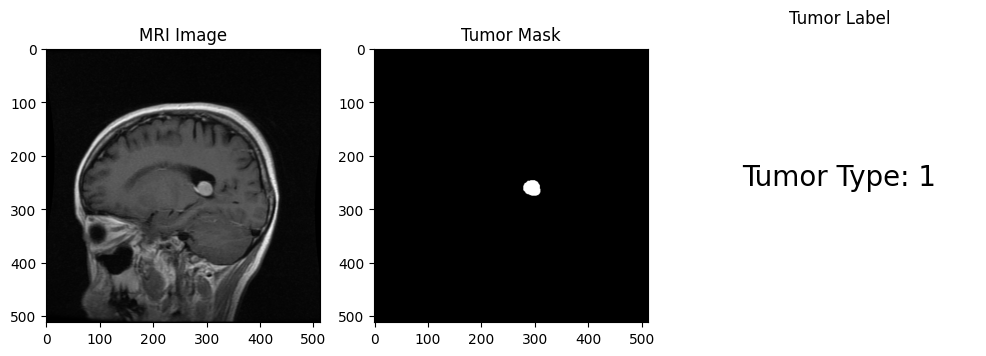

In [14]:
import matplotlib.pyplot as plt

# Function to display image, mask, and label
def display_image_mask_label(image, mask, label):
    plt.figure(figsize=(12, 4))

    # Display the MRI image
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('MRI Image')

    # Display the corresponding mask
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Tumor Mask')

    # Display the label as text
    plt.subplot(1, 3, 3)
    plt.text(0.5, 0.5, f'Tumor Type: {label}', fontsize=20, ha='center')
    plt.title('Tumor Label')
    plt.axis('off')

    plt.show()

# Show the first image, mask, and label as an example
display_image_mask_label(images[0], masks[0], labels[0])


MRI Image: Displayed in grayscale using imshow().
Mask: The mask is a binary array (with True representing the tumor and False the background), so it's also displayed in grayscale.
Label: Shown as text in the third plot, corresponding to the tumor type.

In [17]:
import numpy as np
import cv2

# Define the target size (e.g., 256x256)
target_size = (256, 256)

# Function to resize images and masks
def resize_data(data, target_size):
    resized_data = []
    for item in data:
        # Convert the data type to uint8 for images
        item_uint8 = item.astype(np.uint8) * 255 if item.ndim == 2 else item
        resized_item = cv2.resize(item_uint8, target_size, interpolation=cv2.INTER_NEAREST)
        resized_data.append(resized_item)
    return np.array(resized_data)

# Resize images and masks to the target size
images_resized = resize_data(images, target_size)
masks_resized = resize_data(masks, target_size)

# Add a channel dimension (1 channel for grayscale images)
images_resized = np.expand_dims(images_resized, axis=-1)  # Shape: (num_samples, height, width, 1)
masks_resized = np.expand_dims(masks_resized, axis=-1)    # Shape: (num_samples, height, width, 1)

print("Images resized shape:", images_resized.shape)
print("Masks resized shape:", masks_resized.shape)


Images resized shape: (3064, 256, 256, 1)
Masks resized shape: (3064, 256, 256, 1)


Data Type Conversion: The masks are converted from bool to uint8 by multiplying them by 255. This is because boolean values will be interpreted as 0 and 1, which need to be scaled for correct visualization and processing.
Conditional Check: The conversion is done only if the data is 2D (height and width)

In [18]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.resnet50 import ResNet50
